# Dependancies

In [1]:
!pip3 install langchain langchain_openai langchain_community pypdf rank_bm25 chromadb

In [2]:
!pip3 install ollamafreeapi --upgrade

# Document loader (working only on PDFs for now)

In [1]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("./files/http_codes.pdf")
documents = loader.load()

print(f"Actual Data:\n{documents[0].page_content}\n")
print(f"Meta Data:\n{documents[0].metadata}\n")

print(len(documents))

/var/folders/pl/db9c69xj2x58hx02bxhtd4b40000gq/T/ipykernel_49821/495264697.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Actual Data:
List of HTTP status codes
This article lists standard and notable non-standard HTTP response status codes. Standardized codes are
defined by IETF as documented in Request for Comments (RFC) publications and maintained by the
IANA.[1] Other, non-standard values are used by various servers. The descriptive text after the numeric
code – the reason phrase – is shown here with typical value, but in practice, can be different or omitted.
Status codes defined by IETF are listed below. Emphasized terms must, must not and should are
interpretation guidelines as given by RFC 2119 (https://www.rfc-editor.org/rfc/rfc2119).
An informational response indicates that the request was received and understood and is being processed.
It alerts the client to wait for a final response. The message does not contain a body. As the HTTP/1.0
standard did not define any 1xx status codes, servers must not send a 1xx response to an HTTP/1.0
compliant client except under experimental conditions.
100 Co

# Chunking the document

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000, # 1000 with 100 overlap seems to grab all the error codes so its a good chunk size for now, maybe could change later 
    chunk_overlap = 100,
    separators=["\n\n", "\n", " ", ""] 
)
# texts = text_splitter.create_documents([documents[0].page_content])
texts = text_splitter.split_documents(documents) # Splits documents themselves (pages of the PDF) instead of an array of strings 

import hashlib

#adding unique ids for each of the chunks based on the content in the chunks and the page number so its global to different chunk sizes and then we can persist chunk data without duplicating 
for doc in texts:
    page = doc.metadata.get('page')
    content_hash = hashlib.md5(doc.page_content.encode()).hexdigest()[:8]
    doc.metadata['chunk_id'] = f"page{page}_{content_hash}"

print(texts[0].page_content)
# print(texts[0].metadata)
# print(documents[0].metadata)
# print(texts[3].metadata)
# print(documents[1].metadata)


List of HTTP status codes
This article lists standard and notable non-standard HTTP response status codes. Standardized codes are
defined by IETF as documented in Request for Comments (RFC) publications and maintained by the
IANA.[1] Other, non-standard values are used by various servers. The descriptive text after the numeric
code – the reason phrase – is shown here with typical value, but in practice, can be different or omitted.
Status codes defined by IETF are listed below. Emphasized terms must, must not and should are
interpretation guidelines as given by RFC 2119 (https://www.rfc-editor.org/rfc/rfc2119).
An informational response indicates that the request was received and understood and is being processed.
It alerts the client to wait for a final response. The message does not contain a body. As the HTTP/1.0
standard did not define any 1xx status codes, servers must not send a 1xx response to an HTTP/1.0
compliant client except under experimental conditions.
100 Continue


# Embeddings 

In [5]:
!pip3 install google-genai python-dotenv langchain-google-genai

In [6]:
!pip3 install -U langchain-chroma

In [3]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings as ggenai
from langchain_chroma import Chroma

# from dotenv import load_dotenv
# import time 

# load_dotenv()

ids = [doc.metadata["chunk_id"] for doc in texts]

embeddings = ggenai(model="models/gemini-embedding-001")
vectorDB = Chroma.from_documents(
    texts, 
    embeddings,
    persist_directory="./my_chroma_db",
    ids = ids
    )



# Dense Retrieval 

In [4]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings as ggenai 
from langchain_chroma import Chroma

db  = Chroma(
    persist_directory="./my_chroma_db",
    embedding_function=ggenai(model="models/gemini-embedding-001")
)
query="Expectation failed error"

result = db.similarity_search(query, k = 2)

for i, doc in enumerate(result):
    print(f"--- Result {i+1} (page {doc.metadata.get('page')}) ---")
    print(doc.page_content)
    print()

print(db._collection.count()) # verifying all the chunks have been saved to the persist file 

retriever = db.as_retriever(
    search_kwargs={"k":5} #return the top 5 results
)

docs = retriever.invoke(query)

for i, doc in enumerate(docs):
    print(f"--- Result {i+1} (page {doc.metadata.get('page')}) ---")
    print(doc.page_content)
    print()

--- Result 1 (page 4) ---
of the file. Called "Requested Range Not Satisfiable" previously.[27]: §10.4.17 
417 Expectation Failed
The server cannot meet the requirements of the Expect request-header field.[28]
418 I'm a teapot (RFC 2324, RFC 7168)
This code was defined in 1998 as one of the traditional IETF April Fools' jokes, in RFC
2324, Hyper Text Coffee Pot Control Protocol, and is not expected to be implemented by
actual HTTP servers. The RFC specifies this code should be returned by teapots
requested to brew coffee.[29] This HTTP status is used as an Easter egg in some
websites, such as Google.com's "I'm a teapot" easter egg.[30][31] Sometimes, this status

--- Result 2 (page 5) ---
code is also used as a response to a blocked request, instead of the more appropriate
403 Forbidden.[32][33]
421 Misdirected Request
The request was directed at a server that is not able to produce a response (for example
because of connection reuse).
422 Unprocessable Content
The request was well-for

# BM 25 (Sparse Retrieval) 

In [21]:
!pip3 install spacy

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 27.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.0/661.0 kB 26.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.1/792.1 kB 26.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.6 MB/s  0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 20.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [spacy]m18/19 [spacy]tion]


In [25]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 18.7 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [5]:
from langchain_community.retrievers import BM25Retriever
import spacy 

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"]) # defining a custom pre processing function so that irrelevant chunks are not returned in wordy queries 

def spacy_preprocess_func(text: str) -> list[str]:
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]

bm25_retrieval = BM25Retriever.from_documents(texts, preprocess_func=spacy_preprocess_func)
bm25_retrieval.k = 5

query = "417"

docs = bm25_retrieval.invoke(query)

tokenized_query = bm25_retrieval.preprocess_func(query)
scores = bm25_retrieval.vectorizer.get_scores(tokenized_query)

scored_docs = sorted(zip(bm25_retrieval.docs, scores), key=lambda x: x[1], reverse=True)

# for i, doc in enumerate(docs):
#     print(f"--- Result {i+1} (page {doc.metadata.get('page')}) ---")
#     print(doc.page_content)
#     print()

for doc, score in scored_docs:
    print(f"Score: {score:.4f} | Content: {doc.page_content}")

Score: 3.1071 | Content: RFC 2616 (https://datatracker.ietf.org/doc/html/rfc2616). Obsolete. Obsoleted by RFC 7230
(https://www.rfc-editor.org/rfc/rfc7230), 7231 (https://www.rfc-editor.org/rfc/rfc7231), 7232 (ht
tps://www.rfc-editor.org/rfc/rfc7232), 7233 (https://www.rfc-editor.org/rfc/rfc7233), 7234 (http
s://www.rfc-editor.org/rfc/rfc7234) and 7235 (https://www.rfc-editor.org/rfc/rfc7235).
Obsoletes RFC 2068 (https://www.rfc-editor.org/rfc/rfc2068). Updated by RFC 2817 (https://
www.rfc-editor.org/rfc/rfc2817), 5785 (https://www.rfc-editor.org/rfc/rfc5785), 6266 (https://w
ww.rfc-editor.org/rfc/rfc6266) and 6585 (https://www.rfc-editor.org/rfc/rfc6585).
28. TheDeadLike. "HTTP/1.1 Status Codes 400 and 417, cannot choose which" (http://serverfau
lt.com/questions/433470/http-1-1-status-codes-400-and-417-cannot-choose-which).
serverFault. Archived (https://web.archive.org/web/20151010125107/http://serverfault.com/q
uestions/433470/http-1-1-status-codes-400-and-417-cannot-choose-which) 

# Hybrid Fusion

In [13]:
!pip3 install langchain

In [44]:
from langchain_classic.retrievers import EnsembleRetriever

ensemble_retriever = EnsembleRetriever(retrievers=[bm25_retrieval, retriever], 
                                       weights=[0.6,0.4])

q = "Why am I getting a 403 code?"

docs = ensemble_retriever.invoke(q)

for i, doc in enumerate(docs):
    print(f"--- Result {i+1} (page {doc.metadata.get('page')}) ---")
    print(doc.page_content)
    print()

--- Result 1 (page 3) ---
example blocked fraudulent payments.[24] Cloudflare Turnstile uses this code when
requesting resources with cURL.
403 Forbidden
The request was valid, but the server refuses action. This may be due to the user not
having permission to a resource or needing an account of some sort, or attempting a
prohibited action (e.g. creating a duplicate record where only one is allowed). This code is
also typically used if the request provided authentication by answering the WWW-
Authenticate header field challenge, but the server did not accept that authentication. The
request should not be repeated.
This code differs from 401 in that while 401 is returned when the client has not
authenticated, and implies that a successful response may be returned following valid
authentication, 403 is returned when the client is not permitted access to the resource
despite providing authentication such as insufficient permissions of the authenticated
account.

--- Result 2 (page 3) ---


In [45]:
d1 = retriever.invoke(q)

for i, doc in enumerate(d1):
    print(f"--- Result {i+1} (page {doc.metadata.get('page')}) ---")
    print(doc.page_content)
    print()

d2 = bm25_retrieval.invoke(q)

for i, doc in enumerate(d2):
    print(f"--- Result {i+1} (page {doc.metadata.get('page')}) ---")
    print(doc.page_content)
    print()

--- Result 1 (page 3) ---
example blocked fraudulent payments.[24] Cloudflare Turnstile uses this code when
requesting resources with cURL.
403 Forbidden
The request was valid, but the server refuses action. This may be due to the user not
having permission to a resource or needing an account of some sort, or attempting a
prohibited action (e.g. creating a duplicate record where only one is allowed). This code is
also typically used if the request provided authentication by answering the WWW-
Authenticate header field challenge, but the server did not accept that authentication. The
request should not be repeated.
This code differs from 401 in that while 401 is returned when the client has not
authenticated, and implies that a successful response may be returned following valid
authentication, 403 is returned when the client is not permitted access to the resource
despite providing authentication such as insufficient permissions of the authenticated
account.

--- Result 2 (page 3) ---


In [46]:
the_teapot_footnote_chunk_text = """ 30. Barry Schwartz (August 26, 2014). "New Google Easter Egg For SEO Geeks: Server Status
418, I'm A Teapot" (https://web.archive.org/web/20151115041951/http://searchengineland.co
m/new-google-easter-egg-seo-geeks-server-status-418-im-teapot-201739). Search Engine
Land. Archived from the original (http://searchengineland.com/new-google-easter-egg-seo-g
eeks-server-status-418-im-teapot-201739) on November 15, 2015. Retrieved November 4,
2015.
31. "Error 418 (I'm a teapot)!?" (https://www.google.com/teapot). Retrieved December 17, 2025.
32. "Enable extra web security on a website" (https://help.dreamhost.com/hc/en-us/articles/2159
47927-Enable-extra-web-security-on-a-website). DreamHost. Retrieved December 18,
2022.
33. "I Went to a Russian Website and All I Got Was This Lousy Teapot" (https://www.pcmag.co
m/news/i-went-to-a-russian-website-and-all-i-got-was-this-lousy-teapot). PCMag. February
25, 2022. Retrieved December 18, 2022. """

print(bm25_retrieval.preprocess_func("Why am I getting a 403 code?"))
print(bm25_retrieval.preprocess_func(the_teapot_footnote_chunk_text))

['get', '403', 'code']
['30', 'barry', 'schwartz', 'august', '26', '2014', 'new', 'google', 'easter', 'egg', 'seo', 'geeks', 'server', 'status', '418', 'teapot', 'https://web.archive.org/web/20151115041951/http://searchengineland.co', 'm', 'new', 'google', 'easter', 'egg', 'seo', 'geek', 'server', 'status-418', 'im', 'teapot-201739', 'search', 'engine', 'land', 'archive', 'original', 'http://searchengineland.com/new-google-easter-egg-seo-g', 'eek', 'server', 'status-418', 'im', 'teapot-201739', 'november', '15', '2015', 'retrieve', 'november', '4', '2015', '31', 'error', '418', 'teapot', 'https://www.google.com/teapot', 'retrieve', 'december', '17', '2025', '32', 'enable', 'extra', 'web', 'security', 'website', 'https://help.dreamhost.com/hc/en-us/articles/2159', '47927', 'enable', 'extra', 'web', 'security', 'website', 'dreamhost', 'retrieve', 'december', '18', '2022', '33', 'go', 'russian', 'website', 'get', 'lousy', 'teapot', 'https://www.pcmag.co', 'm', 'news', 'go', 'russian', 'we

# Generation 

In [47]:
def format_docs(docs):
    return "\n\n".join(
        f"[Page {doc.metadata.get('page')}]\n{doc.page_content}"
        for doc in docs
    )

In [48]:
print(format_docs(ensemble_retriever.invoke("Why am I getting a 403 code?")))

[Page 3]
example blocked fraudulent payments.[24] Cloudflare Turnstile uses this code when
requesting resources with cURL.
403 Forbidden
The request was valid, but the server refuses action. This may be due to the user not
having permission to a resource or needing an account of some sort, or attempting a
prohibited action (e.g. creating a duplicate record where only one is allowed). This code is
also typically used if the request provided authentication by answering the WWW-
Authenticate header field challenge, but the server did not accept that authentication. The
request should not be repeated.
This code differs from 401 in that while 401 is returned when the client has not
authenticated, and implies that a successful response may be returned following valid
authentication, 403 is returned when the client is not permitted access to the resource
despite providing authentication such as insufficient permissions of the authenticated
account.

[Page 3]
despite providing authentication s

In [49]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate 
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

qa_prompt = ChatPromptTemplate.from_template("""
Answer the question using only the context provided below. 
If the answer isn't in the context, say you don't know — do not guess.
Cite the page number(s) your answer comes from.

Context:
{context}

Question:
{question}
""")

llm = ChatGoogleGenerativeAI(model = "gemini-3.6-flash", temperature = 0.2)

rag_chain = ( 
                RunnableParallel( context = ensemble_retriever | format_docs, question = RunnablePassthrough() ) |
                qa_prompt | 
                llm
)

In [50]:
response = rag_chain.invoke("Why am I getting a 403 code?")
print(response.text)

/Users/Shahzaib_04/Developer/RAG Intro/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3237: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Based on the provided context, you may receive a **403 Forbidden** status code for the following reasons:

* **Lack of permissions or need for an account:** The user does not have permission to access the resource, has insufficient permissions for their authenticated account, or needs an account [Page 3].
* **Prohibited action:** Attempting an action that is not allowed, such as creating a duplicate record where only one is permitted [Page 3].
* **Unaccepted authentication:** The request answered a `WWW-Authenticate` header challenge, but the server did not accept the authentication [Page 3].
* **Directory listing disabled (Apache / IIS):** Requesting a URL path corresponding to a file system directory when directory listing is disabled/denied and no Directory Index directive exists to specify a file [Page 3].
* **Proxy blocking:** Administrators configured the Mod proxy extension to block the request [Page 3].
* **WebDAV Depth header issues:** Issuing a `PROPFIND` request in WebDAV wi

# Evaluation 

In [51]:
test_queries = {
    "code": [
        "417",
        "403",
        "what does 429 mean",
    ],
    "conceptual": [
        "how does content negotiation work",
        "why might a server respond with 402 payment required",
        "what happens when a resource has been intentionally removed and should not be requested again",
    ],
    "mixed": [
        "why would a WebDAV PROPFIND request fail with a 403 or 424",
        "why did Twitter stop using 420 for rate limiting",
    ],
    "ambiguous_code": [
        "451",
        "420",
        "530",
    ],
}

In [52]:
!pip3 install pandas matplotlib

## Reload persisted data (no re-embedding)

Everything below is rebuilt straight from the already-persisted `./my_chroma_db` directory instead of re-running the PDF load / chunk / embed cells above, so this section can be run on its own without spending Gemini tokens re-embedding the corpus. The only Gemini calls left are the one-embedding-per-query calls that dense/hybrid retrieval need in order to run at all.

In [53]:
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings as ggenai
from langchain_chroma import Chroma
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
import spacy

db = Chroma(
    persist_directory="./my_chroma_db",
    embedding_function=ggenai(model="models/gemini-embedding-001"),
)

# db.get() reads straight out of the sqlite store -- no embedding call happens here
raw = db.get(include=["documents", "metadatas"])
eval_texts = [
    Document(page_content=content, metadata=meta)
    for content, meta in zip(raw["documents"], raw["metadatas"])
]
print(f"Loaded {len(eval_texts)} / {db._collection.count()} persisted chunks (no re-embedding)")

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def spacy_preprocess_func(text: str) -> list[str]:
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]

bm25_retrieval = BM25Retriever.from_documents(eval_texts, preprocess_func=spacy_preprocess_func)
retriever = db.as_retriever(search_kwargs={"k": 5})
ensemble_retriever = EnsembleRetriever(retrievers=[bm25_retrieval, retriever], weights=[0.5, 0.5])


Loaded 63 / 63 persisted chunks (no re-embedding)


## Ground truth labels

Expected page(s) for each test query, found by grepping the persisted chunk text/metadata directly (see below) -- not by asking the LLM -- so this costs zero Gemini tokens. These are what "correct" means for the accuracy metrics further down.

In [54]:
# Expected page(s) for each query, determined by inspecting the persisted chunks'
# content directly (grep over db.get() output) rather than asking the LLM.
ground_truth = {
    "417": {"pages": [4]},
    "403": {"pages": [3]},
    "what does 429 mean": {"pages": [5]},
    "how does content negotiation work": {"pages": [1, 4, 6]},
    "why might a server respond with 402 payment required": {"pages": [3]},
    "what happens when a resource has been intentionally removed and should not be requested again": {"pages": [4]},
    "why would a WebDAV PROPFIND request fail with a 403 or 424": {"pages": [3, 5]},
    "why did Twitter stop using 420 for rate limiting": {"pages": [8]},
    "451": {"pages": [5]},
    "420": {"pages": [8]},
    "530": {"pages": [9]},
}

missing = [q for qs in test_queries.values() for q in qs if q not in ground_truth]
assert not missing, f"Missing ground truth for: {missing}"


## Retrieval results vs. ground truth

Runs every test query through all three retrievers once, tags each returned chunk as relevant/not-relevant against `ground_truth`, and computes per-query Hit@5 / Precision@5 / Recall@5 / Reciprocal Rank in the same pass (so dense/hybrid only get queried once per query, not once per metric).

In [55]:
def run_eval(query, k=5):
    bm25_retrieval.k = k
    retriever.search_kwargs["k"] = k
    return {
        "bm25": bm25_retrieval.invoke(query),
        "dense": retriever.invoke(query),
        "hybrid": ensemble_retriever.invoke(query),
    }

def score(pages, expected, k):
    hits = [p in expected for p in pages[:k]]
    first_hit_rank = next((i + 1 for i, h in enumerate(hits) if h), None)
    return {
        "hit": any(hits),
        "precision_at_k": sum(hits) / k,
        "recall_at_k": len(set(p for p, h in zip(pages, hits) if h) & expected) / len(expected),
        "reciprocal_rank": 1 / first_hit_rank if first_hit_rank else 0.0,
    }

rows, metric_rows = [], []
for bucket, queries in test_queries.items():
    for query in queries:
        expected = set(ground_truth[query]["pages"])
        results = run_eval(query)
        for retriever_name, docs in results.items():
            pages = [doc.metadata.get("page") for doc in docs]
            for rank, doc in enumerate(docs, start=1):
                rows.append({
                    "bucket": bucket,
                    "query": query,
                    "retriever": retriever_name,
                    "rank": rank,
                    "page": pages[rank - 1],
                    "expected_pages": sorted(expected),
                    "relevant": pages[rank - 1] in expected,
                    "snippet": doc.page_content[:80].replace("\n", " ") + "...",
                })
            metric_rows.append({
                "bucket": bucket,
                "query": query,
                "retriever": retriever_name,
                **score(pages, expected, k=5),
            })

import pandas as pd
eval_df = pd.DataFrame(rows)
metrics_df = pd.DataFrame(metric_rows)
eval_df


,bucket,query,retriever,rank,page,expected_pages,relevant,snippet
0,code,417,bm25,1,12,[4],False,RFC 2616 (https://datatracker.ietf.org/doc/htm...
1,code,417,bm25,2,4,[4],True,"of the file. Called ""Requested Range Not Satis..."
2,code,417,bm25,3,0,[4],False,compliant client except under experimental con...
3,code,417,bm25,4,16,[4],False,Hypertext Transfer Protocol (HTTP) Status Code...
4,code,417,bm25,5,4,[4],True,The requested resource could not be found but ...
...,...,...,...,...,...,...,...,...
188,ambiguous_code,530,hybrid,2,9,[9],True,"it, such as CPU/RAM usage or number of concurr..."
189,ambiguous_code,530,hybrid,3,15,[9],False,"59. ""527 Error: Railgun Listener to origin err..."
190,ambiguous_code,530,hybrid,4,9,[9],True,Used by Shopify. 430 Request Header Fields Too...
191,ambiguous_code,530,hybrid,5,1,[9],False,A success status indicates that the action req...


## Aggregate accuracy metrics

Mean of each metric across all test queries, per retriever -- the headline numbers for "how well is BM25 / dense / hybrid actually doing."

In [56]:
summary_df = (
    metrics_df.groupby("retriever")[["hit", "precision_at_k", "recall_at_k", "reciprocal_rank"]]
    .mean()
    .rename(columns={
        "hit": "hit_rate",
        "precision_at_k": "precision@5",
        "recall_at_k": "recall@5",
        "reciprocal_rank": "mrr",
    })
    .reindex(["bm25", "dense", "hybrid"])
    .round(3)
)
summary_df


,hit_rate,precision@5,recall@5,mrr
retriever,,,,
bm25,1.0,0.436,1.000,0.882
dense,1.0,0.400,0.939,0.833
hybrid,1.0,0.400,0.970,0.818


## Visualize retrieval accuracy

In [57]:
!pip3 install matplotlib

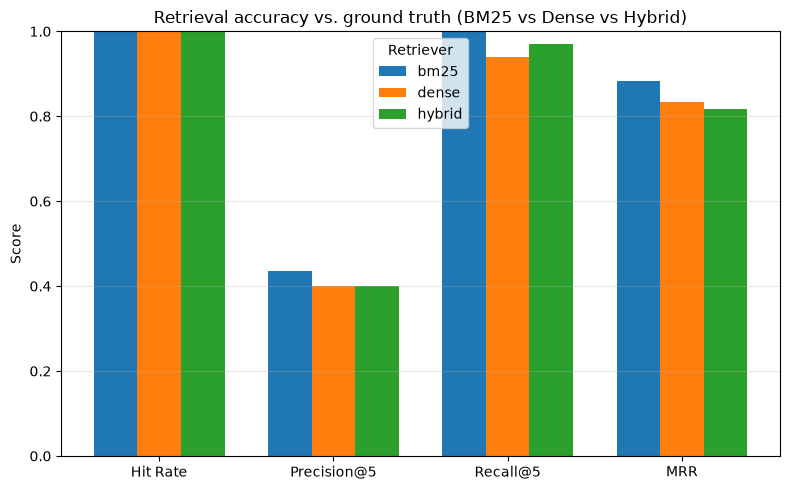

In [58]:
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ["hit_rate", "precision@5", "recall@5", "mrr"]
labels = ["Hit Rate", "Precision@5", "Recall@5", "MRR"]
retrievers = summary_df.index.tolist()
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, name in enumerate(retrievers):
    ax.bar(x + i * width, summary_df.loc[name, metrics_to_plot].values, width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Retrieval accuracy vs. ground truth (BM25 vs Dense vs Hybrid)")
ax.legend(title="Retriever")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


/var/folders/pl/db9c69xj2x58hx02bxhtd4b40000gq/T/ipykernel_49821/162702720.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


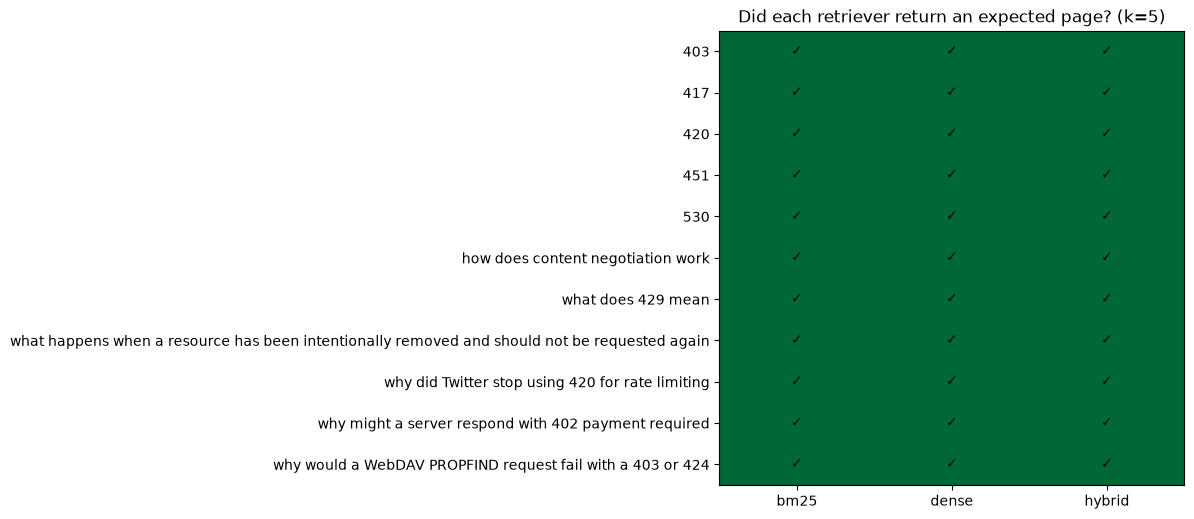

In [59]:
pivot = metrics_df.pivot(index="query", columns="retriever", values="hit").astype(int)
pivot = pivot[["bm25", "dense", "hybrid"]]

fig, ax = plt.subplots(figsize=(6, 0.4 * len(pivot) + 1.5))
ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, "\u2713" if pivot.values[i, j] else "\u2717", ha="center", va="center")
ax.set_title("Did each retriever return an expected page? (k=5)")
plt.tight_layout()
plt.show()


## Per-query breakdown

Same top-k results as before, but each rank is now marked ✓/✗ against the expected page(s) instead of needing to eyeball it.

In [60]:
def compare_query(query, k=5):
    expected = set(ground_truth[query]["pages"])
    print(f"QUERY: {query}")
    print(f"EXPECTED PAGE(S): {sorted(expected)}")
    print("=" * 70)
    for name, docs in run_eval(query, k=k).items():
        print(f"\n--- {name.upper()} (top {len(docs)}) ---")
        for rank, doc in enumerate(docs, start=1):
            page = doc.metadata.get("page")
            mark = "\u2713" if page in expected else " "
            snippet = doc.page_content[:100].replace("\n", " ")
            print(f"  {mark} #{rank} (page {page}): {snippet}...")
    print()

for query in test_queries["mixed"]:
    compare_query(query)


QUERY: why would a WebDAV PROPFIND request fail with a 403 or 424
EXPECTED PAGE(S): [3, 5]

--- BM25 (top 5) ---
  ✓ #1 (page 5): code is also used as a response to a blocked request, instead of the more appropriate 403 Forbidden....
  ✓ #2 (page 3): despite providing authentication such as insufficient permissions of the authenticated account. The ...
  ✓ #3 (page 3): 404 error on Wikimedia submitting a form to a permanently redirected resource may continue smoothly....
  ✓ #4 (page 3): example blocked fraudulent payments.[24] Cloudflare Turnstile uses this code when requesting resourc...
    #5 (page 0): servers).[2]: §10.1.1  101 Switching Protocols The requester has asked the server to switch protocol...

--- DENSE (top 5) ---
  ✓ #1 (page 3): despite providing authentication such as insufficient permissions of the authenticated account. The ...
  ✓ #2 (page 5): code is also used as a response to a blocked request, instead of the more appropriate 403 Forbidden....
  ✓ #3 (page 3): 

In [61]:
for doc in eval_texts:
    print(f"[Page {doc.metadata.get('page')}] {doc.page_content[:100].replace(chr(10), ' ')}...")


[Page 0] List of HTTP status codes This article lists standard and notable non-standard HTTP response status ...
[Page 0] compliant client except under experimental conditions. 100 Continue The server has received the requ...
[Page 0] servers).[2]: §10.1.1  101 Switching Protocols The requester has asked the server to switch protocol...
[Page 1] A success status indicates that the action requested by the client was received, understood, and acc...
[Page 1] 204 No Content The server successfully processed the request, and is not returning any content. 205 ...
[Page 1] (multistatus) response, and are not being included again. 226 IM Used (RFC 3229) The server has fulf...
[Page 1] The link target was moved such that the request and future similar requests should be redirected to ...
[Page 2] Except for a GET request, the body should contain a hyperlink to the new URL(s). Except for a GET or...
[Page 2] GET and 307 which preserves the original request type. Despite the greater clarity prov